In [79]:
# Import libraries

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine 

In [81]:
# Database Connection

In [82]:
server = "DESKTOP-HQ12CUO"
database = "supermarket_sales_database"

In [83]:
connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

In [84]:
# overview of tables 

In [85]:
productsales = pd.read_sql(
    """
    select top 5 *
    from productsalessummary
    """,
    engine
)

productsales

,SalesDate,StoreID,ProductID,Category,UnitsSold,RevenueGross,RevenueNet,TotalDiscount
0,2025-06-01,101,1001,Dairy,320,960.0,810.0,150.0
1,2025-06-01,101,1002,Bakery,280,840.0,720.0,120.0
2,2025-06-01,101,1003,Beverages,410,2050.0,1720.0,330.0
3,2025-06-01,102,1001,Dairy,300,900.0,760.0,140.0
4,2025-06-01,102,1004,Meat,260,1820.0,1540.0,280.0


In [86]:
dailysales = pd.read_sql(
    """
    select top 5 *
    from dailystoresales
    """,
    engine
)

dailysales

,SalesDate,StoreID,TotalSalesGross,TotalSalesNet,TotalTransactions,TotalItemsSold,AverageBasketValue
0,2025-06-01,101,15230.5,12800.4,420,3120,36.26
1,2025-06-01,102,13480.6,11340.3,390,2900,34.56
2,2025-06-01,103,18240.7,15320.8,510,3820,35.77
3,2025-06-02,101,16410.8,13780.2,445,3290,36.89
4,2025-06-02,102,14120.9,11890.1,405,3010,34.87


In [87]:
paymentsinfo = pd.read_sql(
    """
    select top 5 *
    from paymentsummary
    """,
    engine
)

paymentsinfo

,SalesDate,StoreID,PaymentMethod,TotalAmount,TransactionCount
0,2025-06-01,101,Cash,3200.0,90
1,2025-06-01,101,Credit Card,2230.5,40
2,2025-06-01,101,EC Card,9800.0,290
3,2025-06-01,102,Cash,2900.0,85
4,2025-06-01,102,EC Card,8600.0,260


In [ ]:
# checking for na and null values in the tables

In [89]:
print(productsales.isna().sum())

SalesDate        0
StoreID          0
ProductID        0
Category         0
UnitsSold        0
RevenueGross     0
RevenueNet       0
TotalDiscount    0
dtype: int64


In [90]:
print(productsales.isnull().sum())

SalesDate        0
StoreID          0
ProductID        0
Category         0
UnitsSold        0
RevenueGross     0
RevenueNet       0
TotalDiscount    0
dtype: int64


In [91]:
print(dailysales.isna().sum())

SalesDate             0
StoreID               0
TotalSalesGross       0
TotalSalesNet         0
TotalTransactions     0
TotalItemsSold        0
AverageBasketValue    0
dtype: int64


In [92]:
print(dailysales.isnull().sum())

SalesDate             0
StoreID               0
TotalSalesGross       0
TotalSalesNet         0
TotalTransactions     0
TotalItemsSold        0
AverageBasketValue    0
dtype: int64


In [93]:
print(paymentsinfo.isna().sum())

SalesDate           0
StoreID             0
PaymentMethod       0
TotalAmount         0
TransactionCount    0
dtype: int64


In [94]:
print(paymentsinfo.isnull().sum())

SalesDate           0
StoreID             0
PaymentMethod       0
TotalAmount         0
TransactionCount    0
dtype: int64


In [95]:
# Gross Revenue by Store

revenue_store = pd.read_sql(
    """
    select
        storeid as "Store_ID",
        sum(revenuegross) as "Gross_Revenue"
    from productsalessummary
    group by storeid;
    """,
    engine
)

revenue_store

,Store_ID,Gross_Revenue
0,101,15640.0
1,102,13470.0
2,103,9340.0


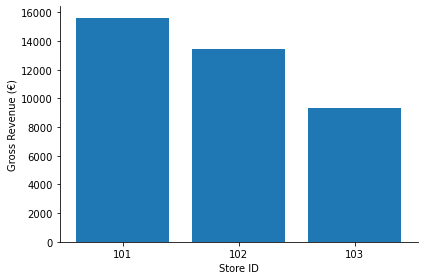

In [105]:
# chart

revenue_store["Store_ID"] = revenue_store["Store_ID"].astype(str)

plt.figure(facecolor="white")
plt.bar(revenue_store["Store_ID"], revenue_store["Gross_Revenue"])
plt.xlabel("Store ID")
plt.ylabel("Gross Revenue (€)")

rbl = plt.gca()
rbl.spines['right'].set_visible(False)
rbl.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [97]:
# Transaction Frequency by Payment Method 

paymentmethod_revenue = pd.read_sql(
    """
    select 
        paymentmethod as "Payment_Method", 
        sum(transactioncount) as "Transaction_Frequency" 
    from paymentsummary
    group by paymentmethod
    """,
    engine
) 

paymentmethod_revenue

,Payment_Method,Transaction_Frequency
0,Cash,710
1,Credit Card,160
2,EC Card,2855


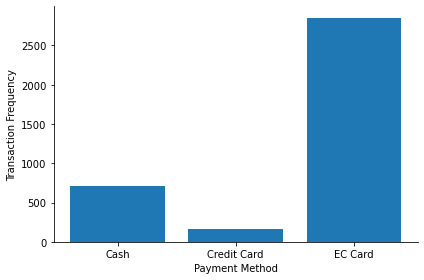

In [106]:
# chart 

paymentmethod_revenue["Payment_Method"] = paymentmethod_revenue["Payment_Method"].astype(str)

plt.figure(facecolor="white")
plt.bar(paymentmethod_revenue["Payment_Method"], paymentmethod_revenue["Transaction_Frequency"])
plt.xlabel("Payment Method")
plt.ylabel("Transaction Frequency")

pfg = plt.gca()
pfg.spines['right'].set_visible(False)
pfg.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [99]:
# Gross Revenue by Product Category

revenue_product_category = pd.read_sql(
    """
    select 
        category as "Category", 
        sum(RevenueGross) as "Gross_Revenue" 
    from productsalessummary
    group by Category
    """,
    engine
) 

revenue_product_category

,Category,Gross_Revenue
0,Bakery,3615.0
1,Beverages,10775.0
2,Dairy,6000.0
3,Meat,9870.0
4,Produce,8190.0


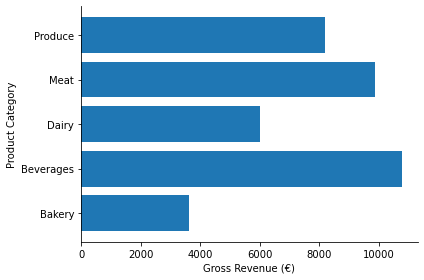

In [107]:
# chart 

revenue_product_category["Category"] = revenue_product_category["Category"].astype(str)

plt.figure(facecolor="white")
plt.barh(revenue_product_category["Category"], revenue_product_category["Gross_Revenue"])
plt.xlabel("Gross Revenue (€)")
plt.ylabel("Product Category")

cfg = plt.gca()
cfg.spines['right'].set_visible(False)
cfg.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

In [101]:
# The Stores that earned above the Average Gross Revenue (€12,816.67)

beyond_average_revenue = pd.read_sql(
    """
    select
        storeid as "Store_ID",
        sum(revenuegross) as "Gross_Revenue"
    from productsalessummary
    group by storeid
    having sum(revenuegross) > 12816.67;
    """,
    engine
)

beyond_average_revenue

,Store_ID,Gross_Revenue
0,101,15640.0
1,102,13470.0


In [102]:
# Net Revenue by Store

store_net_revenue = pd.read_sql(
    """
    with net_revenue_product as (
        select 
            storeid, 
            category, 
            sum(revenuenet) as "sum_of_net_revenue"
        from productsalessummary
        group by storeid, category)

    select 
        storeid as "Store_ID", 
        sum(sum_of_net_revenue) as "Net_Revenue"
    from net_revenue_product
    group by storeid;   
    """, 
    engine
)

store_net_revenue

,Store_ID,Net_Revenue
0,101,13180.0
1,102,11355.0
2,103,7870.0


In [104]:
# discount impact on sale volumes at Store 101 

discount_sale_volume = pd.read_sql(
    """
    select *
    from (
        select
            storeid AS "Store_ID",
            category AS "Category",
            unitssold AS "Units_Sold",
            totaldiscount AS "Total_Discounts",
            rank() over (partition by storeid order by unitssold desc) as "Ranked_Sale_Units"
        from productsalessummary
    ) ranked
    where "Store_ID" = 101;
    """,
    engine
)

discount_sale_volume

,Store_ID,Category,Units_Sold,Total_Discounts,Ranked_Sale_Units
0,101,Produce,580,270.0,1
1,101,Produce,550,260.0,2
2,101,Beverages,445,355.0,3
3,101,Beverages,420,340.0,4
4,101,Beverages,410,330.0,5
5,101,Dairy,340,160.0,6
6,101,Dairy,330,150.0,7
7,101,Dairy,320,150.0,8
8,101,Meat,295,325.0,9
9,101,Bakery,280,120.0,10
